Loading the Datasets

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/Pharma_data.csv", encoding='latin1')

/tmp/ipykernel_1355/2957460476.py:4: DtypeWarning: Columns (0,1,2,3,4,5,6,7,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Pharma_data.csv", encoding='latin1')


Inspect Data

In [17]:
print("First 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nSummary Statistics:\n", df.describe(include='all'))

First 5 rows:
                                         PRODUCTID PRODUCTNDC  \
0  0002-1200_4bd46cbe-cdc1-4329-a8e7-22816bd7fc33  0002-1200   
1  0002-1407_14757f9d-f641-4836-acf3-229265588d1d  0002-1407   
2  0002-1433_aaae85ae-9295-465f-b938-463b74b8d5bd  0002-1433   
3  0002-1434_aaae85ae-9295-465f-b938-463b74b8d5bd  0002-1434   
4  0002-1445_2ecde4c5-5128-4725-9cf5-64384857eb1c  0002-1445   

           PRODUCTTYPENAME      PROPRIETARYNAME PROPRIETARYNAMESUFFIX  \
0  HUMAN PRESCRIPTION DRUG               Amyvid                   NaN   
1  HUMAN PRESCRIPTION DRUG  Quinidine Gluconate                   NaN   
2  HUMAN PRESCRIPTION DRUG            Trulicity                   NaN   
3  HUMAN PRESCRIPTION DRUG            Trulicity                   NaN   
4  HUMAN PRESCRIPTION DRUG                TALTZ                   NaN   

    NONPROPRIETARYNAME       DOSAGEFORMNAME     ROUTENAME  STARTMARKETINGDATE  \
0     Florbetapir F 18  INJECTION, SOLUTION   INTRAVENOUS          20120601.0   

Check data quality

In [18]:
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# Standardize categorical values (if columns exist)
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].astype(str).str.strip().str.capitalize()
if 'Disease' in df.columns:
    df['Disease'] = df['Disease'].astype(str).str.strip().str.capitalize()
if 'Medication' in df.columns:
    df['Medication'] = df['Medication'].astype(str).str.strip().str.capitalize()

# Handle missing values (example: fill Age with median)
if 'Age' in df.columns and df['Age'].isnull().sum() > 0:
    df['Age'] = df['Age'].fillna(df['Age'].median())


Missing values per column:
 PRODUCTID                     83619
PRODUCTNDC                    83619
PRODUCTTYPENAME               83619
PROPRIETARYNAME               83620
PROPRIETARYNAMESUFFIX        109075
NONPROPRIETARYNAME            83622
DOSAGEFORMNAME                83619
ROUTENAME                     84374
STARTMARKETINGDATE            83619
ENDMARKETINGDATE             113538
MARKETINGCATEGORYNAME         83619
APPLICATIONNUMBER             86043
LABELERNAME                   83619
SUBSTANCENAME                 84508
ACTIVE_NUMERATOR_STRENGTH     84508
ACTIVE_INGRED_UNIT            84508
PHARM_CLASSES                 98604
DEASCHEDULE                  112425
dtype: int64

Duplicate rows: 83618


Basic Analysis

In [19]:
print("\nTotal patients:", len(df))

if 'Disease' in df.columns:
    print("\nDisease frequency:\n", df['Disease'].value_counts())

if 'Medication' in df.columns:
    print("\nMedication frequency:\n", df['Medication'].value_counts())

if 'Age' in df.columns:
    print("\nAverage age of patients:", df['Age'].mean())

if 'Medication' in df.columns and 'Dosage (mg)' in df.columns:
    avg_dosage = df.groupby('Medication')['Dosage (mg)'].mean()
    print("\nAverage dosage per medication:\n", avg_dosage)

if 'Gender' in df.columns and 'Disease' in df.columns:
    gender_disease = df.groupby(['Gender','Disease']).size()
    print("\nDisease count by gender:\n", gender_disease)


Total patients: 30605


Insights

In [20]:
if 'Age' in df.columns and 'Dosage (mg)' in df.columns:
    correlation = df[['Age','Dosage (mg)']].corr()
    print("\nCorrelation between Age and Dosage:\n", correlation)

if 'Disease' in df.columns and 'Gender' in df.columns:
    pivot = pd.pivot_table(df, values='Age', index='Disease', columns='Gender', aggfunc='mean')
    print("\nAverage Age by Disease and Gender:\n", pivot)

if 'Disease' in df.columns:
    print("\nTop 3 Diseases:\n", df['Disease'].value_counts().head(3))
if 'Medication' in df.columns:
    print("\nTop 3 Medications:\n", df['Medication'].value_counts().head(3))

Visualization

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

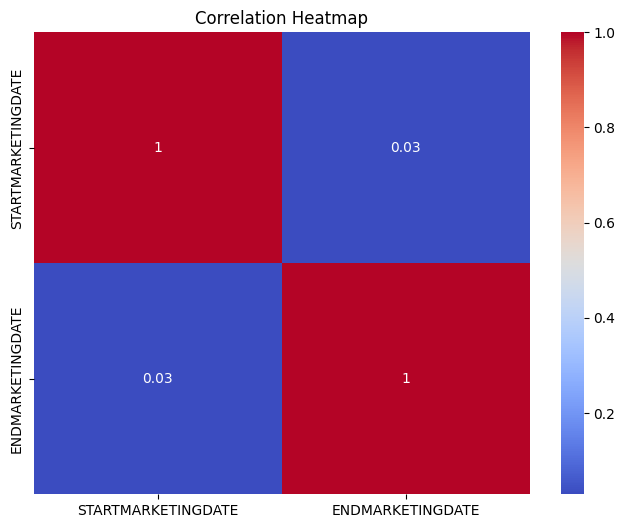


Summary report saved as Pharma_data_summary.txt

Cleaned dataset saved as Pharma_data_cleaned.csv


In [23]:
plt.figure(figsize=(10,5))
if 'Disease' in df.columns:
    sns.countplot(x='Disease', data=df, palette='Set2')
    plt.title("Disease Frequency")
    plt.xticks(rotation=45)
    plt.show()

plt.figure(figsize=(10,5))
if 'Age' in df.columns:
    sns.histplot(df['Age'], bins=10, kde=True, color='skyblue')
    plt.title("Age Distribution of Patients")
    plt.show()

if 'Medication' in df.columns and 'Dosage (mg)' in df.columns:
    plt.figure(figsize=(10,5))
    sns.barplot(x=avg_dosage.index, y=avg_dosage.values, palette='Set1')
    plt.title("Average Dosage per Medication")
    plt.xticks(rotation=45)
    plt.show()

if 'Age' in df.columns and 'Dosage (mg)' in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x='Age', y='Dosage (mg)', hue='Disease', data=df, palette='Set2')
    plt.title("Age vs Dosage by Disease")
    plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# 7. Export summary report
with open("Pharma_data_summary.txt", "w") as f:
    f.write("Total patients: " + str(len(df)) + "\n")
    if 'Age' in df.columns:
        f.write("Average age: " + str(df['Age'].mean()) + "\n")
    if 'Disease' in df.columns:
        f.write("Most common disease: " + str(df['Disease'].mode()[0]) + "\n")
    if 'Medication' in df.columns:
        f.write("Most common medication: " + str(df['Medication'].mode()[0]) + "\n")

print("\nSummary report saved as Pharma_data_summary.txt")

# 8. Save cleaned dataset
df.to_csv("Pharma_data_cleaned.csv", index=False)
print("\nCleaned dataset saved as Pharma_data_cleaned.csv")
